In [1]:
from anomaly_detection.utils.scoring import QuantileScorer
import numpy as np
import matplotlib.pyplot as plt
import torch

In [7]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import minmax_scale_per_sample
full_dataset = load_dataset("FJ")
full_dataset = minmax_scale_per_sample(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch


<BarContainer object of 96 artists>

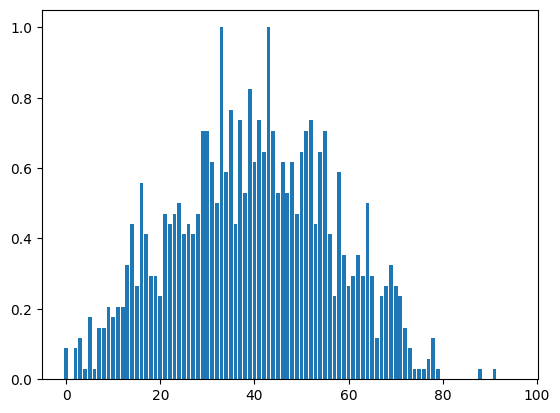

In [9]:
plt.bar(range(96), full_dataset[46])

<BarContainer object of 96 artists>

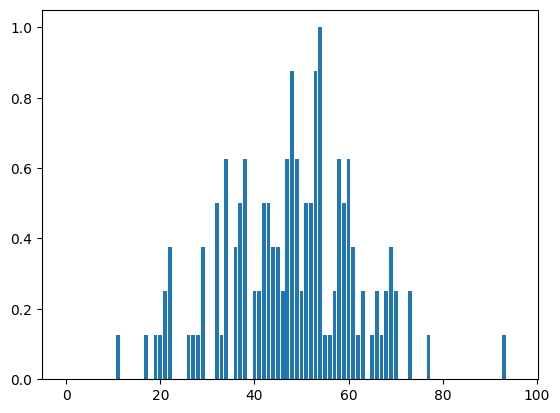

In [10]:
plt.bar(range(96), full_dataset[244])

mean: 0.7352941
i: 92.14999999999999


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_29840\1136434629.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residual = np.abs(full_dataset[244] - full_dataset[46])


<BarContainer object of 96 artists>

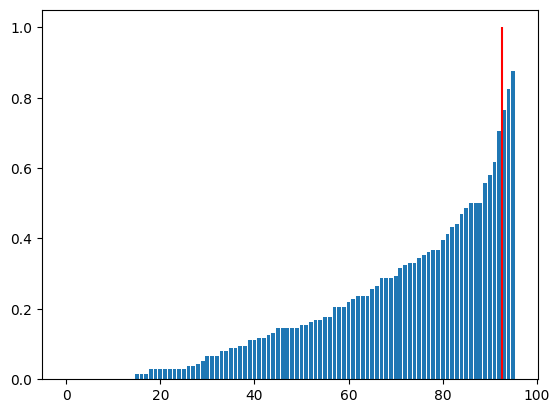

In [ ]:
residual = np.abs(full_dataset[244] - full_dataset[46])
residual = sorted(residual)
q = 0.75
i = q * (96-1)

i_up = np.ceil(i)
i_down = np.floor(i)
print('mean:', np.mean((residual[int(i_up)], residual[int(i_down)])))

print("i:", i)
plt.vlines(np.mean((i_up, i_down)), ymin=0, ymax=1, zorder=2, color='red')
plt.bar(range(96), residual, zorder=0)

In [29]:
scorer = QuantileScorer(q=q)
scorer.score(full_dataset[244], full_dataset[46])

tensor(0.7147)